# Deep-learning forecasts with NeuralForecast

This notebook benchmarks 15 architectures through their NeuralForecast `Auto*` implementations: recurrent baselines (AutoRNN, AutoLSTM, AutoGRU), attention models (AutoVanillaTransformer, AutoAutoformer, AutoPatchTST, AutoiTransformer, AutoTFT), the convolutional representative AutoTimesNet, MLP/linear models (AutoNLinear, AutoTSMixer, AutoTiDE), basis-expansion models (AutoNBEATS, AutoNHITS), and the KAN representative AutoKAN. The networks are evaluated on the original target: as discussed in the thesis methodology, they can learn trend and seasonality internally, so the classical/ML AutoStationary comparison is not repeated here. Forecasts are direct multi-horizon forecasts.


## Validation, early stopping, and final test protocol

Deep learning needs two validation levels during selection. With `EVALUATION_SPLIT='validation'`, the external validation horizon compares architectures/configurations, while the last `dl['val_size']` observations inside the training partition control early stopping and Optuna's trial selection. With `'test'`, the notebook loads each frozen validation winner, replaces its `Auto*` wrapper with the resolved base architecture, disables Optuna and early stopping, fits on every train+validation observation, and evaluates the untouched test horizon once.

Synthetic benchmarking is confined to balanced 100-series global panels in `global_models.ipynb`, where all 15 architectures are retained. This notebook is exclusively the manual-dataset architecture-selection workflow.

Every candidate uses a NeuralForecast `Auto*` wrapper with the same dataset-specific Optuna-TPE budget. EMAE uses four trials, including two seeded startup trials. `max_steps=1000` is a common upper bound for every trial, not a value selected by Optuna: validation is checked every 10 steps and training can stop after 20 consecutive checks without improvement. Reaching 1,000 means that the early-stopping criterion did not fire before the ceiling; it does not by itself prove that more steps would improve generalization. Context lengths are dataset-defined: EMAE searches 12, 24, 36, and 48 monthly observations rather than inheriting half-hourly London windows.

TimesNet is the convolutional representative because its period-aware 1D-to-2D transformation can capture intra-period and inter-period variation, a useful inductive bias for seasonal and synthetic series. KAN is retained as the single KAN-family baseline because it isolates spline-parameterized edge functions without adding RMoK's mixture/gating mechanism; AutoRMoK is also unavailable in the installed NeuralForecast 1.7.4 release. With EMAE alone, iTransformer and TSMixer have only one channel, so their cross-series mixing advantage is not active; they become more meaningful in the later global experiment. Their `batch_size` controls sampled temporal windows and is kept above one because TSMixer uses BatchNorm. TFT is also evaluated without exogenous variables here, so this benchmark does not exercise its variable-selection advantage.


In [1]:
import copy
import os
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display

from thesis.data_preparation import (
    MANUAL_DATASETS, POINT_FORECAST_DATASETS,
    create_train_val_test_splits, load_dataset,
)
from thesis.dl_benchmark import run_dl_benchmark
from thesis.dl_evaluation import (
    DL_MODEL_NAMES, evaluate_dl_models, load_dl_configs, model_parameters,
)
from thesis.evaluation import (
    build_results_table, export_comparison_metrics,
    export_results_table_latex,
    export_results_tables_latex, plot_forecast_matplotlib,
    prepare_comparison_metrics, style_results_table,
)
from thesis.model_selection import (
    export_model_selection, filter_metrics_to_selection,
    load_model_selection, selected_base_models, summarize_model_selection,
)
from thesis.reporting import (
    apply_matplotlib_dataset_labels, display_series_name, figure_path,
    humanize_results_table, save_matplotlib_figure,
)
%load_ext autoreload
%autoreload 2


In [2]:
SEED = 67
# Batch mode loops over manual datasets in one run; it does not create a global model.
EXECUTION_MODE = 'batch'  # 'single' or 'batch'
ACTIVE_DATASET = 'emae'  # used only in single mode
EVALUATION_SPLIT = 'test'  # 'validation' or 'test'
SELECTED_MODELS = list(DL_MODEL_NAMES)
DL_CONFIG_DIR = Path('thesis/model_configs/dl')
# Optional dataset/model overrides:
# {'emae': {'NLinear': {'learning_rate': 1e-3}}}
DL_CONFIG_OVERRIDES_BY_DATASET = {}
SAVE_FIGURES = True
FIGURE_FORMAT = 'jpg'

assert EXECUTION_MODE in {'single', 'batch'}
assert EVALUATION_SPLIT in {'validation', 'test'}
random.seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.set_float32_matmul_precision('high')
if EXECUTION_MODE == 'single':
    datasets_to_process = [ACTIVE_DATASET]
else:
    datasets_to_process = list(POINT_FORECAST_DATASETS)
SELECTION_PATH = Path('thesis/model_configs/dl_validation_selection.json')
os.makedirs('thesis/metrics', exist_ok=True)
os.makedirs('thesis/results', exist_ok=True)
print(
    f'Datasets ({len(datasets_to_process)}): {datasets_to_process} | '
    f'Evaluation: {EVALUATION_SPLIT} | Candidate architectures: {len(SELECTED_MODELS)}'
)
if EXECUTION_MODE != 'single':
    print('ACTIVE_DATASET is ignored outside single mode.')

Datasets (4): ['emae', 'ecai_us', 'real_gdp_argentina', 'real_gdp_us'] | Evaluation: test | Candidate architectures: 15
ACTIVE_DATASET is ignored outside single mode.


## Dataset-aware Auto configurations

Underscore-prefixed JSON fields record provenance and adaptations and are never passed to NeuralForecast. Each dataset's nested `dl` settings define the context candidates, inner validation size, common trial count, TPE startup count, and common `max_steps` ceiling; optional dataset/model overrides keep later architecture changes explicit. A global NeuralForecast model uses one common context length for every series in a training run, so series requiring materially different windows should be grouped or trained separately.

All 15 architectures use Optuna for every manual dataset. Trial durations are recorded separately from the frozen-configuration refits, while `Time Elapsed` includes the relevant tuning, refitting, and forecasting cost. Training, early stopping, and Optuna selection minimize MSE, which is aligned with the primary RMSE selection metric; exported results still report every common metric. Equal trial counts and step ceilings make the computational rule consistent, although architecture-specific search spaces naturally differ in dimension and per-step cost. Detailed progress messages identify the dataset, tuning or refitting phase, architecture, elapsed time, and observed-time ETA.


In [3]:
base_dl_configs = load_dl_configs(DL_CONFIG_DIR, SELECTED_MODELS)
audit_dataset_config = MANUAL_DATASETS.get(ACTIVE_DATASET, {}) if EXECUTION_MODE == 'single' else {}
audit_dl_settings = audit_dataset_config.get('dl', {})
config_audit = pd.DataFrame([
    {
        'Model': model_name,
        'Source': config.get('_source'),
        'Adaptations': '; '.join(config.get('_adaptations', [])),
        'Seed': config.get('random_seed'),
        'Procedure': (
            f"Optuna TPE ({audit_dl_settings.get('auto_num_samples', config['_auto']['num_samples'])} trials)"
        ),
        'Input Size': 'dataset-defined candidates',
        'Training Loss': 'MSE (RMSE-aligned)',
        'Max Steps': audit_dl_settings.get('auto_max_steps', config.get('max_steps')),
        'Early Stopping': (
            f"{config.get('early_stop_patience_steps')} checks; "
            f"validate every {config.get('val_check_steps')} steps"
        ),
    }
    for model_name, config in base_dl_configs.items()
])
display(config_audit)


,Model,Source,Adaptations,Seed,Procedure,Input Size,Training Loss,Max Steps,Early Stopping
0,AutoRNN,NeuralForecast AutoRNN search space; Rumelhart...,Optuna TPE; seed=67; dataset-defined input-siz...,67,Optuna TPE (10 trials),dataset-defined candidates,MSE (RMSE-aligned),1000,20 checks; validate every 10 steps
1,AutoLSTM,NeuralForecast AutoLSTM search space; Hochreit...,Optuna TPE; seed=67; dataset-defined input-siz...,67,Optuna TPE (10 trials),dataset-defined candidates,MSE (RMSE-aligned),1000,20 checks; validate every 10 steps
2,AutoGRU,NeuralForecast AutoGRU search space; Cho et al...,Optuna TPE; seed=67; dataset-defined input-siz...,67,Optuna TPE (10 trials),dataset-defined candidates,MSE (RMSE-aligned),1000,20 checks; validate every 10 steps
3,AutoVanillaTransformer,NeuralForecast AutoVanillaTransformer search s...,Optuna TPE; seed=67; dataset-defined input-siz...,67,Optuna TPE (10 trials),dataset-defined candidates,MSE (RMSE-aligned),1000,20 checks; validate every 10 steps
4,AutoAutoformer,NeuralForecast AutoAutoformer search space; Wu...,Optuna TPE; seed=67; dataset-defined input-siz...,67,Optuna TPE (10 trials),dataset-defined candidates,MSE (RMSE-aligned),1000,20 checks; validate every 10 steps
5,AutoPatchTST,NeuralForecast AutoPatchTST search space; Nie ...,Optuna TPE; seed=67; dataset-defined input-siz...,67,Optuna TPE (10 trials),dataset-defined candidates,MSE (RMSE-aligned),1000,20 checks; validate every 10 steps
6,AutoiTransformer,NeuralForecast AutoiTransformer search space; ...,Optuna TPE; seed=67; dataset-defined input-siz...,67,Optuna TPE (10 trials),dataset-defined candidates,MSE (RMSE-aligned),1000,20 checks; validate every 10 steps
7,AutoTFT,NeuralForecast AutoTFT search space; Lim et al...,Optuna TPE; seed=67; dataset-defined input-siz...,67,Optuna TPE (10 trials),dataset-defined candidates,MSE (RMSE-aligned),1000,20 checks; validate every 10 steps
8,AutoTimesNet,NeuralForecast AutoTimesNet search space; Wu e...,selected CNN family representative; Optuna TPE...,67,Optuna TPE (10 trials),dataset-defined candidates,MSE (RMSE-aligned),1000,20 checks; validate every 10 steps
9,AutoNLinear,NeuralForecast AutoNLinear search space; Zeng ...,Optuna TPE; seed=67; dataset-defined input-siz...,67,Optuna TPE (10 trials),dataset-defined candidates,MSE (RMSE-aligned),1000,20 checks; validate every 10 steps


In [4]:
all_results, dl_configs_by_dataset, dl_selection, benchmark_protocol = run_dl_benchmark(
    dataset_names=datasets_to_process,
    evaluation_split=EVALUATION_SPLIT,
    base_configs=base_dl_configs,
    selection_path=SELECTION_PATH,
    overrides=DL_CONFIG_OVERRIDES_BY_DATASET,
    seed=SEED,
)
frozen_selection = dl_selection if EVALUATION_SPLIT == 'test' else None

print(
    f"Completed {len(all_results)} dataset(s) under the "
    'manual-dataset validation/test protocol.'
)



[test dataset 1/4: emae] models=['AutoPatchTST'] | series=1 | Optuna disabled


Seed set to 67
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


[test dataset 1/4: emae] | fixed refit: model 1/1 (AutoPatchTST) started


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_steps=1000` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Seed set to 67
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[test dataset 1/4: emae] | fixed refit: model 1/1 (AutoPatchTST) completed in 20s | phase elapsed 20s | phase ETA 0s

[test dataset 2/4: ecai_us] models=['AutoTiDE'] | series=1 | Optuna disabled
[test dataset 2/4: ecai_us] | fixed refit: model 1/1 (AutoTiDE) started


...

[test dataset 2/4: ecai_us] | fixed refit: model 1/1 (AutoTiDE) completed in 14s | phase elapsed 14s | phase ETA 0s

[test dataset 3/4: real_gdp_argentina] models=['AutoNBEATS'] | series=1 | Optuna disabled
[test dataset 3/4: real_gdp_argentina] | fixed refit: model 1/1 (AutoNBEATS) started


`Trainer.fit` stopped: `max_steps=1000` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Seed set to 67
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[test dataset 3/4: real_gdp_argentina] | fixed refit: model 1/1 (AutoNBEATS) completed in 14s | phase elapsed 14s | phase ETA 0s

[test dataset 4/4: real_gdp_us] models=['AutoiTransformer'] | series=1 | Optuna disabled
[test dataset 4/4: real_gdp_us] | fixed refit: model 1/1 (AutoiTransformer) started


`Trainer.fit` stopped: `max_steps=1000` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[test dataset 4/4: real_gdp_us] | fixed refit: model 1/1 (AutoiTransformer) completed in 15s | phase elapsed 15s | phase ETA 0s
Completed 4 dataset(s) under the manual-dataset validation/test protocol.


## Results on the original target

In [5]:
all_tables = {}
for dataset_name, data in all_results.items():
    table = build_results_table(
        data['metrics'], id_col=data['id_col'], dataset_type=data['type']
    )
    if 'Validation Selection' in data['metrics']:
        selection_status = (
            data['metrics'].groupby('Model')['Validation Selection'].first()
        )
        table.insert(
            2, 'Validation Selection', table['Model'].map(selection_status)
        )
    table = humanize_results_table(table, dataset_name)
    all_tables[dataset_name] = {'Original': table}
    print(f'{dataset_name} - Original')
    display(style_results_table(table))

emae - Original


,Model,MAE,MSE,RMSE,Forecast Bias,Time Elapsed
0,AutoPatchTST,2.3976,7.7967,2.7923,-0.06,19.932044


ecai_us - Original


,Model,MAE,MSE,RMSE,Forecast Bias,Time Elapsed
0,AutoTiDE,0.1833,0.0456,0.2136,-0.13,13.373487


real_gdp_argentina - Original


,Model,MAE,MSE,RMSE,Forecast Bias,Time Elapsed
0,AutoNBEATS,7935.3547,72115053.0791,8492.0582,-4.29,13.529740


real_gdp_us - Original


,Model,MAE,MSE,RMSE,Forecast Bias,Time Elapsed
0,AutoiTransformer,15.0219,292.2448,17.0952,0.20,15.007634


## Validation-only architecture selection

The saved selection contains the original-target winner at series and dataset levels. Validation runs merge the active dataset into the persistent selection registry, so a single-dataset run cannot erase earlier choices. Test mode loads this file and never selects from test errors.

In [6]:
selection_metric = dl_selection['selection_metric']
print('DEEP-LEARNING VALIDATION SELECTION')
for dataset_name, series_winners in dl_selection['per_series'].items():
    for series_name, target_winners in series_winners.items():
        for target_version, winner in target_winners.items():
            if target_version != 'Original':
                continue
            print(
                f'{dataset_name} / {series_name} / {target_version}: '
                f"{winner['model']} ({selection_metric.upper()}="
                f"{winner['validation_score']:.6f})"
            )

DEEP-LEARNING VALIDATION SELECTION
ecai_us / ECAI_US / Original: AutoTiDE (RMSE=0.209936)
emae / EMAE / Original: AutoPatchTST (RMSE=3.879276)
real_gdp_argentina / REAL_GDP_ARGENTINA / Original: AutoNBEATS (RMSE=3543.677971)
real_gdp_us / REAL_GDP_US / Original: AutoiTransformer (RMSE=21.933079)


## Forecast plots: validation-selected winners only

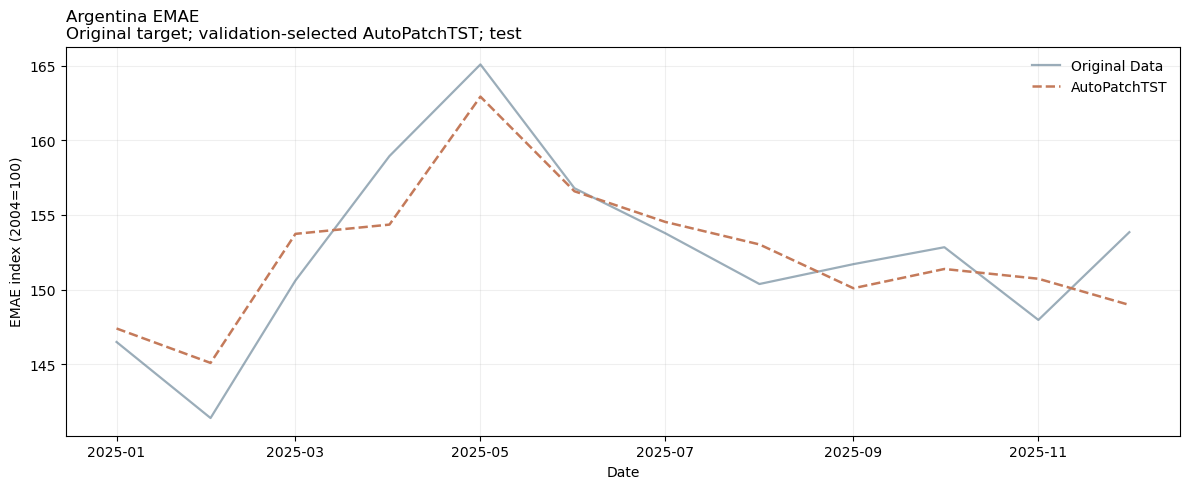

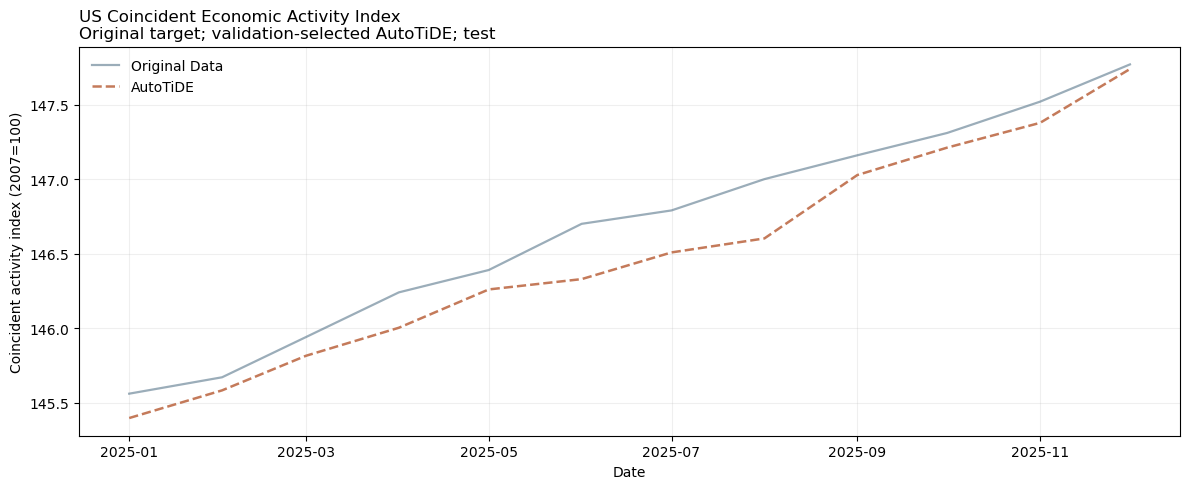

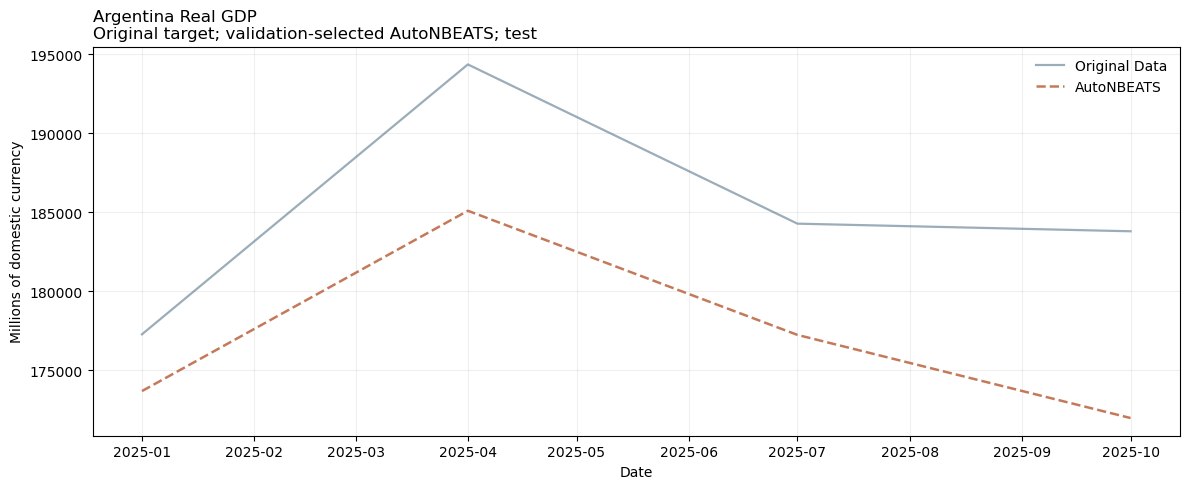

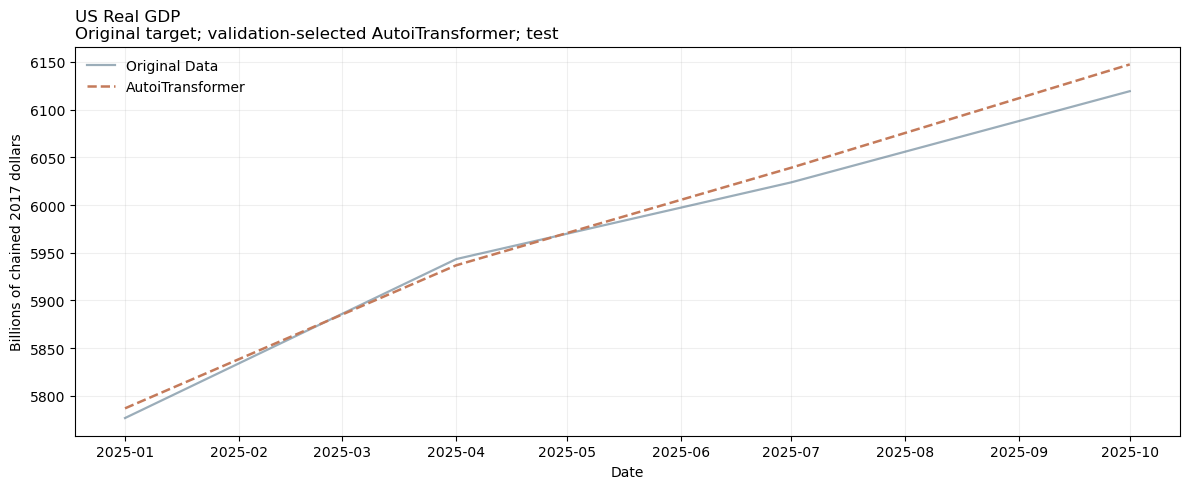

In [7]:
for dataset_name, data in all_results.items():
    series_selections = dl_selection['per_series'].get(dataset_name, {})
    if not series_selections:
        print(f'{dataset_name}: no winner plot (reported negative control).')
        continue
    for series_name, target_winners in series_selections.items():
        plot_series_name = series_name
        plot_series_label = display_series_name(dataset_name, series_name)
        series_results = data['results'][
            data['results'][data['id_col']].astype(str) == str(plot_series_name)
        ]
        winner = target_winners['Original']
        forecast_column = winner['model']
        fig = plot_forecast_matplotlib(
            series_results, [forecast_column], data['time_col'],
            target_col=data['target_col'],
            forecast_display_names=[winner['base_model']],
        )
        apply_matplotlib_dataset_labels(
            fig, dataset_name,
            title_suffix=(
                f'Original target; '
                f"validation-selected {winner['base_model']}; {EVALUATION_SPLIT}"
            ),
        )
        save_matplotlib_figure(
            fig,
            figure_path(
                'dl_models', dataset_name, 'Original', EVALUATION_SPLIT,
                winner['base_model'], extension=FIGURE_FORMAT,
            ),
            SAVE_FIGURES,
        )
        plt.show()
        plt.close(fig)

## LaTeX tables and portable metric exports

Result and runtime LaTeX files are split-specific. Final test errors are the headline performance estimates; validation errors document selection, and the validation runtime table records the full optimization cost.


In [8]:
dl_comparison_tables = []
for dataset_name, data in all_results.items():
    latex_path = export_results_tables_latex(
        all_tables[dataset_name], dataset_name,
        method_name=f'dl_{EVALUATION_SPLIT}',
    )
    runtime_columns = [
        'Preprocessing Time', 'Tuning Time', 'Training Time',
        'Forecast Time', 'Time Elapsed',
    ]
    available_runtime_columns = [
        column for column in runtime_columns if column in data['metrics']
    ]
    runtime_table = (
        data['metrics']
        .groupby(['Model', 'Target Transformation'], as_index=False, dropna=False)
        [available_runtime_columns]
        .mean()
    )
    runtime_path = export_results_table_latex(
        runtime_table, dataset_name,
        method_name=f'dl_{EVALUATION_SPLIT}_runtime',
    )
    comparison_table = prepare_comparison_metrics(
        data['metrics'],
        dataset_name=dataset_name, dataset_type=data['type'],
        series_col=data['id_col'], model_family='Deep Learning',
        split=EVALUATION_SPLIT,
    )
    paths = export_comparison_metrics(
        comparison_table, f'dl_models_{EVALUATION_SPLIT}', dataset_name
    )
    dl_comparison_tables.append(comparison_table)
    print(f'LaTeX: {latex_path}')
    print(f"Metrics CSV: {paths['csv']}")
    print(f'Runtime LaTeX: {runtime_path}')

if dl_comparison_tables:
    dl_metrics_all = pd.concat(dl_comparison_tables, ignore_index=True)
    if EXECUTION_MODE == 'batch':
        export_comparison_metrics(
            dl_metrics_all, f'dl_models_{EVALUATION_SPLIT}', 'all'
        )
    else:
        print('Single mode leaves the complete batch metrics_all file unchanged.')

# End-of-run EMAE and batch-output verification.
emae_frame, emae_config = load_dataset('emae', 'manual')
_, emae_validation, emae_test, emae_id, emae_time, emae_target = (
    create_train_val_test_splits(emae_frame, emae_config, 'manual')
)
assert emae_validation.groupby(emae_id).size().eq(12).all()
assert emae_test.groupby(emae_id).size().eq(12).all()
assert pd.DatetimeIndex(
    pd.to_datetime(emae_test[emae_time]).drop_duplicates().sort_values()
).equals(pd.date_range('2025-01-01', '2025-12-01', freq='MS'))
if 'emae' in all_results:
    emae_run = all_results['emae']
    emae_predictions = emae_run['results'].copy()
    emae_predictions[emae_time] = pd.to_datetime(emae_predictions[emae_time])
    expected_dates = pd.date_range(
        '2024-01-01' if EVALUATION_SPLIT == 'validation' else '2025-01-01',
        periods=12, freq='MS',
    )
    assert pd.DatetimeIndex(
        emae_predictions[emae_time].drop_duplicates().sort_values()
    ).equals(expected_dates)
    compared_models = emae_run['metrics']['Model'].drop_duplicates().tolist()
    assert set(compared_models).issubset(emae_predictions.columns)
    for model_name in compared_models:
        model_dates = pd.DatetimeIndex(
            emae_predictions.loc[
                emae_predictions[model_name].notna(), emae_time
            ].drop_duplicates().sort_values()
        )
        assert model_dates.equals(expected_dates), model_name
    if EVALUATION_SPLIT == 'test':
        fit_dates = pd.to_datetime(emae_run['fit_df'][emae_time])
        assert fit_dates.max() < expected_dates.min()
        december = emae_predictions.loc[
            emae_predictions[emae_time].eq(pd.Timestamp('2025-12-01'))
        ]
        assert len(december) == 1
        assert december[compared_models].notna().all().all()
if EXECUTION_MODE == 'batch':
    expected_batch = set(POINT_FORECAST_DATASETS)
    assert set(all_results) == expected_batch
    assert set(all_tables) == expected_batch
    assert set(dl_metrics_all['Dataset']) == expected_batch
    saved_all = pd.read_csv(
        f'thesis/metrics/dl_models_{EVALUATION_SPLIT}_metrics_all.csv'
    )
    assert set(saved_all['Dataset']) == expected_batch
    for dataset_name in expected_batch:
        table_path = Path(
            f'thesis/results/results_table_dl_{EVALUATION_SPLIT}_{dataset_name}.tex'
        )
        assert table_path.is_file() and table_path.stat().st_size > 0
print('EMAE horizon and batch-consolidation checks passed.')

LaTeX: thesis/results\results_table_dl_test_emae.tex
Metrics CSV: thesis/metrics\dl_models_test_metrics_emae.csv
Runtime LaTeX: thesis/results\results_table_dl_test_runtime_emae.tex
LaTeX: thesis/results\results_table_dl_test_ecai_us.tex
Metrics CSV: thesis/metrics\dl_models_test_metrics_ecai_us.csv
Runtime LaTeX: thesis/results\results_table_dl_test_runtime_ecai_us.tex
LaTeX: thesis/results\results_table_dl_test_real_gdp_argentina.tex
Metrics CSV: thesis/metrics\dl_models_test_metrics_real_gdp_argentina.csv
Runtime LaTeX: thesis/results\results_table_dl_test_runtime_real_gdp_argentina.tex
LaTeX: thesis/results\results_table_dl_test_real_gdp_us.tex
Metrics CSV: thesis/metrics\dl_models_test_metrics_real_gdp_us.csv
Runtime LaTeX: thesis/results\results_table_dl_test_runtime_real_gdp_us.tex
EMAE horizon and batch-consolidation checks passed.


In [ ]:
comparison_parts = [dl_metrics_all]
for method in ('classical_models', 'ml_models'):
    path = Path(
        f'thesis/metrics/{method}_{EVALUATION_SPLIT}_metrics_all.csv'
    )
    if path.exists():
        comparison_parts.append(pd.read_csv(path))
combined_metrics = pd.concat(comparison_parts, ignore_index=True)
display(
    combined_metrics.sort_values(
        ['Dataset', 'Series Name', 'Target Transformation', 'RMSE']
    )
)

,Dataset,Dataset Type,Series Name,Model Family,Model,Target Transformation,Configuration Source,Split,MAE,MSE,RMSE,Forecast Bias,Preprocessing Time,Tuning Time,Training Time,Forecast Time,Time Elapsed,Best Iteration
6,ecai_us,manual,ECAI_US,Classical,AutoETS_AutoStationary,AutoStationary,NaN,test,0.171901,4.995089e-02,0.223497,-0.117202,NaN,NaN,NaN,NaN,0.098765,NaN
21,ecai_us,manual,ECAI_US,Machine Learning,XGBRandomForest_AutoStationary,AutoStationary,NaN,test,0.830668,6.993324e-01,0.836261,-0.566348,NaN,0.0,0.091090,0.021361,0.112450,NaN
22,ecai_us,manual,ECAI_US,Ensemble,RidgeBlend_ClassicalML_AutoStationary,AutoStationary,Validation-trained Ridge blend of the best cla...,test,1.525415,2.370421e+00,1.539617,1.040026,0.0,0.0,0.000924,0.000137,0.001060,NaN
20,ecai_us,manual,ECAI_US,Machine Learning,LightGBM_AutoStationary,AutoStationary,NaN,test,1.802412,3.258012e+00,1.804996,-1.228882,NaN,0.0,0.139139,0.017436,0.156575,697.0
1,ecai_us,manual,ECAI_US,Deep Learning,AutoTiDE,Original,NeuralForecast AutoTiDE search space; Das et a...,test,0.183349,4.564052e-02,0.213636,-0.125007,0.0,0.0,13.289547,0.083940,13.373487,NaN
7,ecai_us,manual,ECAI_US,Classical,AutoTBATS,Original,NaN,test,0.206341,5.901410e-02,0.242928,-0.140683,NaN,NaN,NaN,NaN,2.516987,NaN
23,ecai_us,manual,ECAI_US,Ensemble,RidgeBlend_ClassicalML,Original,Validation-trained Ridge blend of the best cla...,test,1.168424,1.410761e+00,1.187755,0.796630,0.0,0.0,0.000849,0.000128,0.000976,NaN
19,ecai_us,manual,ECAI_US,Machine Learning,XGBRandomForest,Original,NaN,test,2.926708,9.043510e+00,3.007243,-1.995426,NaN,0.0,0.118731,0.015045,0.133775,NaN
18,ecai_us,manual,ECAI_US,Machine Learning,LightGBM,Original,NaN,test,3.514042,1.282638e+01,3.581394,-2.395870,NaN,0.0,0.102961,0.010520,0.113481,202.0
16,emae,manual,EMAE,Ensemble,RidgeBlend_ClassicalML_AutoStationary,AutoStationary,Validation-trained Ridge blend of the best cla...,test,2.207110,6.500386e+00,2.549585,-0.630904,0.0,0.0,0.000675,0.000143,0.000817,NaN


: 